# Docker &amp; Containerization
## A Practical Workshop — Build Once, Run Anywhere (including Zion)

**Amii — Engineering &amp; Performance**  ·  Amirreza Yasami

Hands-on sandbox: [https://github.com/amirrezayasami-amii/amii-workshop-sandbox](https://github.com/amirrezayasami-amii/amii-workshop-sandbox)

---

This notebook builds a small, self-contained scratch project on disk (a tiny FastAPI + ML-style service) and containerizes it step by step. The runnable cells create files and, where Docker is installed, build and run a real image locally — they touch nothing else on your machine and the scratch folder can be deleted afterwards.

Cells shown as **fenced blocks inside markdown** — anything that pushes to a registry, or that runs on a remote host such as **Zion** — are provided for reference and are deliberately **not** executed during the session. Replace every `<PLACEHOLDER>` with your real value before running them.

---


## Why we are here

You have already seen the three pillars of a shared codebase: **Git &amp; GitHub**, **testing**, and **CI/CD**. Containers are the fourth: they take the code that passes your tests in CI and turn it into a single artifact that runs **identically** on your laptop, in CI, and on a shared server.

The one-sentence promise: *"It works on my machine"* becomes *"It works in this image — here is the image."*

## Agenda

1. **Why containers** — the reproducibility problem they solve
2. **Mental model** — images vs. containers, layers, the engine
3. **A scratch service** — the thing we will containerize
4. **The Dockerfile** — build a real image, layer by layer
5. **Run it** — ports, volumes, environment, logs, exec
6. **Slim &amp; fast** — `.dockerignore` &amp; layer caching
7. **Registries** — tag and push to **Docker Hub** and **GitHub Container Registry (ghcr.io)**
8. **CI/CD tie-in** — build &amp; push the image from GitHub Actions
9. **Compose** — more than one container
10. **Podman** — the rootless, drop-in alternative
11. **Apptainer / Singularity** — the HPC runtime
12. **Running on Zion** — SSH, direct run, GPUs, and Slurm submission
13. **Best practices &amp; wrap-up**


## Prerequisites and first-time check

You need one container engine installed to follow the local demos. Any one of these works — the commands are nearly identical:

- **Docker Desktop** (Mac/Windows) or **Docker Engine** (Linux) — the default in this notebook.
- **Podman** — rootless, daemonless, drop-in. `alias docker=podman` and most cells just work.

The cell below checks what you have. If nothing is installed you can still run every *file-writing* cell and read along; the `docker build`/`run` cells simply won't have an engine to talk to.


In [1]:
!docker --version || echo "Docker not found — Podman or Apptainer sections still apply"
!docker compose version 2>/dev/null || echo "Compose plugin not found (optional)"
import sys, platform
print("Python:", sys.version.split()[0])
print("Host:  ", platform.system(), platform.machine())

Docker version 29.6.1, build 8900f1d
Docker Compose version v5.3.0
Python: 3.12.13
Host:   Darwin arm64


## Why containers — the problem they actually solve

Before containers, "shipping software" meant shipping *instructions*: install Python 3.11, these 40 libraries at these exact versions, this system library, set these environment variables, and hope the target machine matches. Every difference between your machine and the server is a chance for a silent failure.

A **container** ships the *result* instead: your code **and** its entire userspace environment — interpreter, libraries, system packages, files — as one immutable image. The only thing it borrows from the host is the Linux kernel.

| Concern | Virtual Machine | Container |
|---|---|---|
| Boots a full guest OS | Yes (minutes, GBs) | No — shares the host kernel (seconds, MBs) |
| Isolation | Strong (hardware-level) | Process-level (namespaces + cgroups) |
| Startup | Slow | Fast |
| Density | Few per host | Many per host |
| Right tool for | Different OS, hard multi-tenant isolation | Packaging &amp; shipping an app reproducibly |

For an ML/engineering team the payoff is concrete: the image that passed CI is *byte-for-byte* the image that runs on Zion. No "works on my machine."


## How containers work — an accurate mental model

Three nouns do most of the work. Get these right and the commands stop feeling arbitrary.

### Image, container, registry

- **Image** — a read-only *template*: a stack of filesystem layers plus metadata (default command, env, exposed ports). Think of it as a class.
- **Container** — a *running (or stopped) instance* of an image, with a thin writable layer on top. Think of it as an object. Many containers can come from one image.
- **Registry** — a *server that stores images* so others (and Zion) can pull them. Docker Hub and ghcr.io are registries.

<figure style="text-align:center;margin:1.4em 0">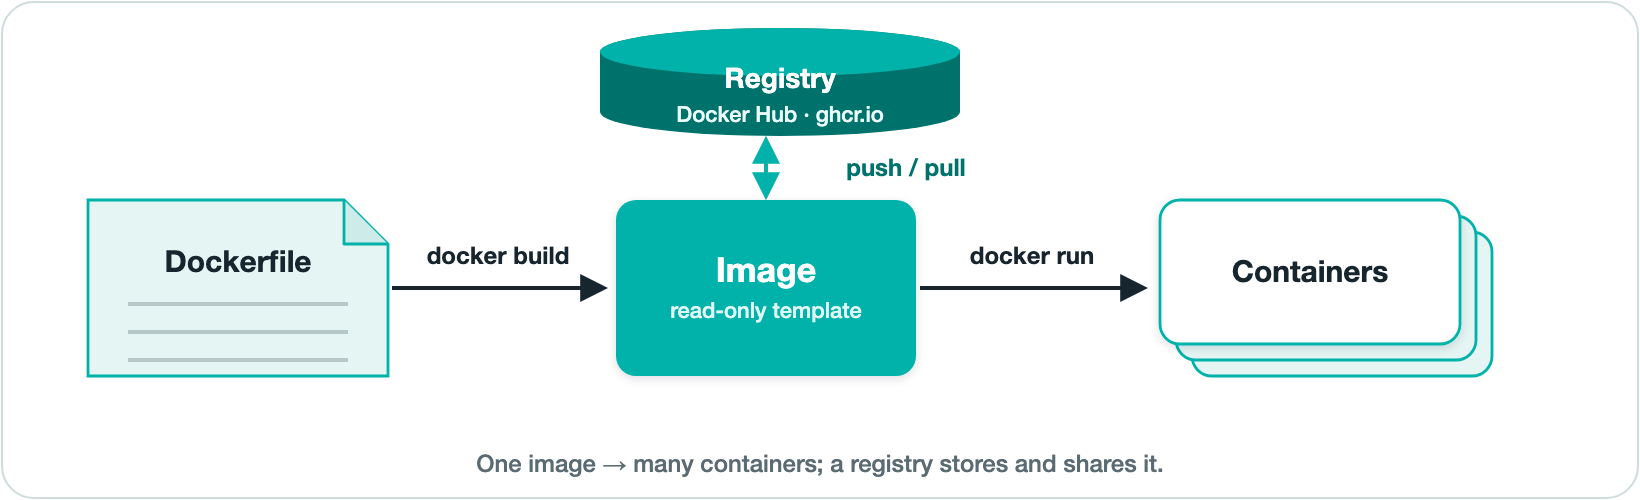<figcaption style="font-size:12.5px;color:#5B6B73;margin-top:8px;line-height:1.45"><b>Figure 1.</b> Build a <code>Dockerfile</code> into an <b>image</b>, run the image to get one or more <b>containers</b>, and push/pull images through a <b>registry</b> to share them (e.g. with Zion).</figcaption></figure>

### Layers &amp; the build cache

An image is built in **layers**, one per instruction in the Dockerfile. Each layer is cached and content-addressed. If a layer's inputs haven't changed, Docker reuses the cache instead of rebuilding — which is why **instruction order matters**: put the things that rarely change (installing dependencies) *before* the things that change every commit (copying your source). We'll exploit this deliberately.

<figure style="text-align:center;margin:1.4em 0">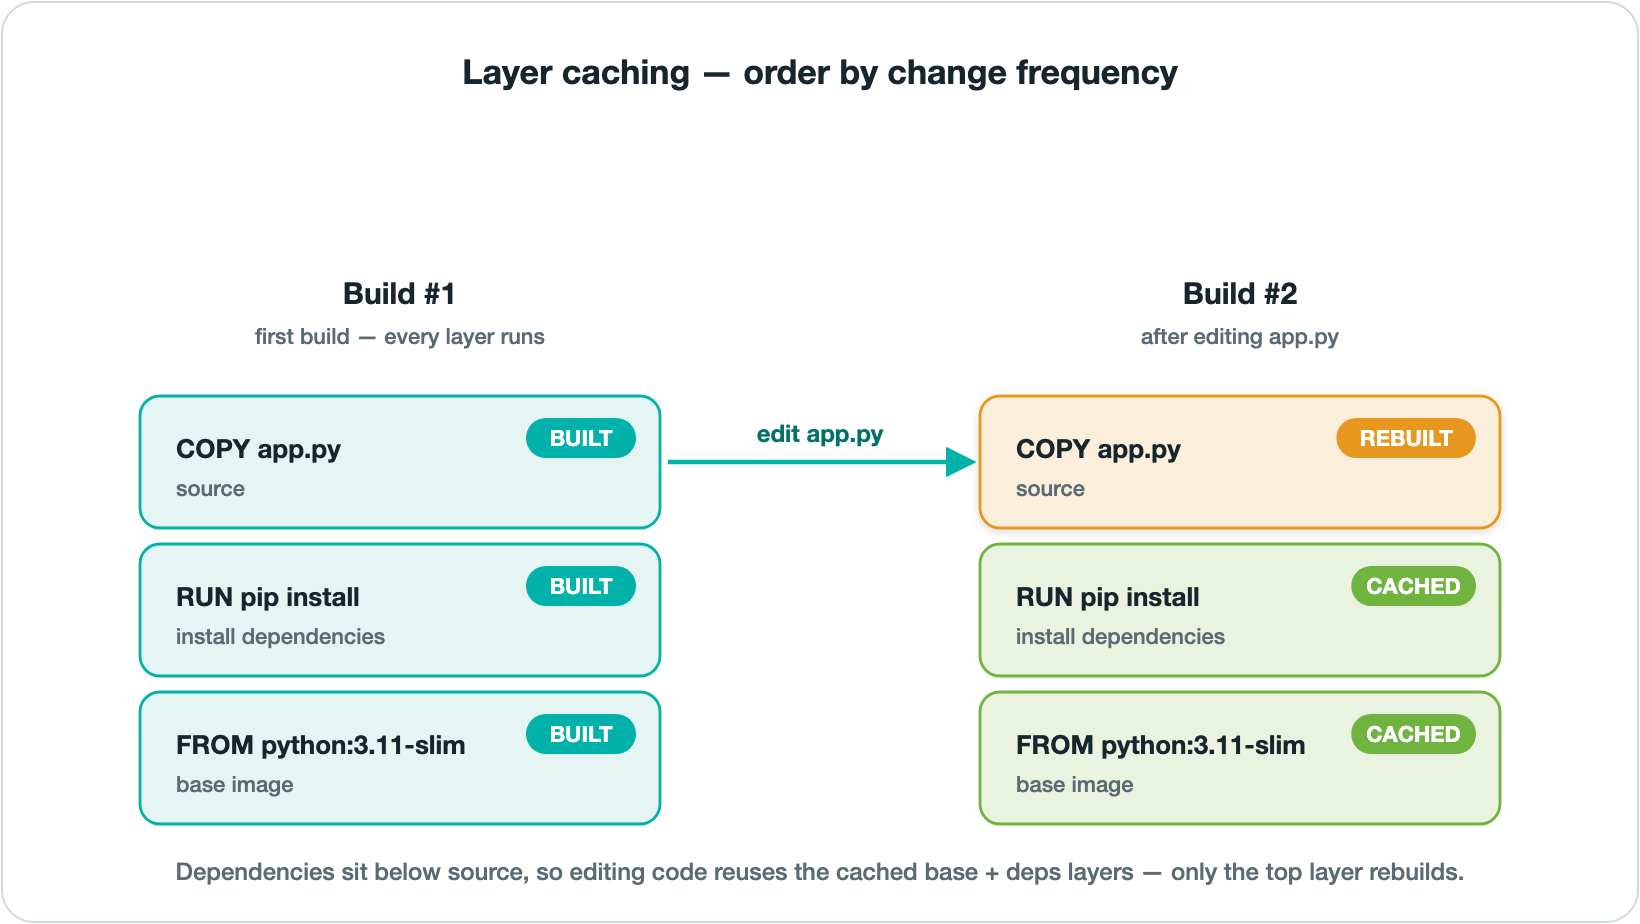<figcaption style="font-size:12.5px;color:#5B6B73;margin-top:8px;line-height:1.45"><b>Figure 2.</b> Because dependencies are installed <i>before</i> the source is copied, editing <code>app.py</code> only invalidates the top layer — Docker reuses the cached base and dependency layers, so the rebuild is fast.</figcaption></figure>

### The engine

`docker` (the CLI) talks to a background **engine/daemon** that actually builds images and runs containers using Linux kernel features — **namespaces** (isolate what a process can see: PIDs, network, mounts) and **cgroups** (limit what it can use: CPU, memory). On a Mac or Windows host, that Linux kernel lives inside a tiny VM that Docker Desktop manages for you.


## A scratch service to containerize

We'll create a tiny but realistic service on disk: a FastAPI app that loads a trivial "model" and exposes a prediction endpoint. It's small enough to reason about and real enough that every containerization concept applies unchanged to your actual projects.

The next cell creates a scratch directory and writes the app. Run it.


In [2]:
import os, pathlib, textwrap
ROOT = pathlib.Path.cwd() / "docker-workshop-sandbox"
ROOT.mkdir(exist_ok=True)
os.chdir(ROOT)
print("Working in:", ROOT)

Working in: /Users/amirreza.yasami/Desktop/docker-workshop-sandbox


In [3]:
%%writefile app.py
"""A tiny FastAPI service with a stand-in 'model'. Nothing here is Docker-specific —
that is the point: ordinary code becomes portable once it is containerized."""
import os
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="amii-container-demo")

# A stand-in for a trained model artifact: weights we would normally load from disk.
WEIGHTS = {"intercept": 1.5, "slope": 2.0}
GREETING = os.environ.get("GREETING", "hello from the container")


class Point(BaseModel):
    x: float


@app.get("/")
def root():
    return {"message": GREETING, "hostname": os.uname().nodename}


@app.get("/health")
def health():
    return {"status": "ok"}


@app.post("/predict")
def predict(p: Point):
    y = WEIGHTS["intercept"] + WEIGHTS["slope"] * p.x
    return {"x": p.x, "y_pred": y}


Overwriting app.py


In [4]:
%%writefile requirements.txt
fastapi==0.115.0
uvicorn[standard]==0.30.6
pydantic==2.9.2


Overwriting requirements.txt


### Pin your dependencies

Notice the **exact versions** in `requirements.txt`. Reproducibility is the whole reason we're here — an unpinned `fastapi` would let the image drift over time and quietly break. Pin everything that goes into an image.


## The Dockerfile — a recipe for the image

A `Dockerfile` is an ordered list of instructions. Each one produces a layer. Here is the whole thing; we'll read it line by line below.


In [5]:
%%writefile Dockerfile
# 1. Start from a small, official, *pinned* base image.
FROM python:3.11-slim

# 2. Don't buffer stdout/stderr; don't write .pyc files. Cleaner container logs.
ENV PYTHONUNBUFFERED=1 \
    PYTHONDONTWRITEBYTECODE=1

# 3. Everything below happens inside this directory in the image.
WORKDIR /app

# 4. Copy ONLY the dependency manifest first, then install.
#    This layer is cached and reused on every build where requirements.txt
#    is unchanged — so editing app.py does NOT reinstall your dependencies.
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 5. Now copy the source. This layer changes on nearly every commit,
#    so it sits AFTER the expensive install to preserve the cache.
COPY app.py .

# 6. Document the port the app listens on (does not publish it by itself).
EXPOSE 8000

# 7. Run as a non-root user — a container should not run as root by default.
RUN useradd --create-home appuser
USER appuser

# 8. The default process for a container started from this image.
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


Overwriting Dockerfile


### Reading the Dockerfile

- **`FROM python:3.11-slim`** — every image starts *from* another image. `-slim` is a smaller Debian variant: fewer packages, smaller attack surface, faster pulls. Pin the tag; avoid `latest`.
- **`ENV`** — bakes environment variables into the image.
- **`WORKDIR /app`** — sets (and creates) the working directory for later instructions and at runtime.
- **`COPY requirements.txt .` then `RUN pip install ...` — *before* copying source.** This is the single most important caching trick: dependency installs are slow and rarely change, so give them their own early layer. Source changes then rebuild only the fast final layers.
- **`EXPOSE 8000`** — documentation/metadata. You still publish the port at `run` time with `-p`.
- **`USER appuser`** — drop root. If the container is ever compromised, the process isn't root inside it.
- **`CMD [...]`** — the default command the container runs when it starts (the *why* is important enough that it gets its own note below). `0.0.0.0` (not `127.0.0.1`) is essential: the app must listen on all interfaces to be reachable from *outside* the container.

### Why we need `CMD` — a container *is* its main process

This is the part that trips people up, so it's worth stating plainly: **a container is not a little virtual machine that boots up and waits for you to log in. A container is a single process.** When you `docker run` an image, Docker starts exactly one command — and the container lives for **precisely as long as that command runs**. When the command exits, the container stops. There is no "idle, empty container" sitting around.

So the image *must* declare what that one command is. That's what `CMD` does:

```dockerfile
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
```

Without it, the container would have nothing to run and would exit immediately (or fall back to the base image's command). With it, `docker run amii-container-demo:0.1` needs no extra arguments — Docker launches uvicorn, uvicorn stays running in the foreground serving requests, and therefore the container stays up. **That's the whole reason our container keeps running: its main process (the web server) never returns.**

A few consequences worth internalizing:

- **The command must run in the *foreground*.** `uvicorn ...` (no `&`, no daemonizing) blocks and keeps serving — good. If you background your server and the `CMD` returns, the container dies instantly, even though "the server started." A container needs its main process to *stay* in the foreground.
- **`CMD` is only the *default* — it's easily overridden.** Anything after the image name on `docker run` replaces it: `docker run amii-container-demo:0.1 python -c "print(1+1)"` runs that instead. Handy for one-off tasks against the same image.
- **`CMD` vs `RUN`** — don't confuse them. `RUN` executes at **build time** to *create a layer* (e.g. `pip install`). `CMD` executes at **run time** and is *not* baked into a layer; it just records the default process.
- **`CMD` vs `ENTRYPOINT`** — `ENTRYPOINT` sets a fixed executable that always runs; `CMD` supplies default *arguments* to it (or the whole default command when there's no `ENTRYPOINT`). For a single app, `CMD` alone is the simplest choice.
- **Prefer the JSON/"exec" form** — `CMD ["uvicorn", ...]` runs the process directly (PID 1), so it receives `Ctrl-C`/`docker stop` signals and shuts down cleanly. The shell form, `CMD uvicorn ...`, wraps it in `/bin/sh -c`, which can swallow those signals.

This also connects two things later in the notebook: because a container dies when its main process exits, a container that *isn't* meant to run a long-lived service (a dev box you just want to `exec` into) needs a command that deliberately never returns — which is exactly what the `tail -f /dev/null` trick in the local-development section provides.

### `.dockerignore` — keep junk out of the build

Just like `.gitignore`, a `.dockerignore` keeps files out of the *build context* sent to the engine. This makes builds faster and images cleaner, and avoids accidentally baking secrets or huge data files into an image.


In [6]:
%%writefile .dockerignore
__pycache__/
*.pyc
.venv/
.git/
.gitignore
.env
*.md
data/
*.ipynb_checkpoints

Overwriting .dockerignore


## Build the image

`docker build` reads the `Dockerfile`, executes each instruction, and produces a tagged image. `-t` names it `name:tag`; the trailing `.` is the **build context** (the current directory).

If Docker is installed, run this live. Watch the output: the first build runs every step; a second build (after editing only `app.py`) reuses the cached dependency layer and finishes in a second or two.


In [8]:
!docker build -t amii-container-demo:0.1 .

[+] Building 0.0s (0/1)                                    docker:desktop-linux
[+] Building 0.2s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 1.12kB                                     0.0s
 => [internal] load metadata for docker.io/library/python:3.11-slim        0.2s
[+] Building 0.3s (2/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 1.12kB                                     0.0s
 => [internal] load metadata for docker.io/library/python:3.11-slim        0.2s
[+] Building 0.4s (10/11)                                  docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 1.12kB                                     0.0s
 => [internal] load metadata for docker.

In [9]:
# Inspect what you just built.
!docker images amii-container-demo
!echo '---'
!docker history amii-container-demo:0.1

                                                            i Info →   U  In Use
IMAGE                     ID             DISK USAGE   CONTENT SIZE   EXTRA
amii-container-demo:0.1   ccace5b58779        262MB         56.7MB        
---
IMAGE          CREATED        CREATED BY                                      SIZE      COMMENT
ccace5b58779   21 hours ago   CMD ["uvicorn" "app:app" "--host" "0.0.0.0" …   0B        buildkit.dockerfile.v0
<missing>      21 hours ago   USER appuser                                    0B        buildkit.dockerfile.v0
<missing>      21 hours ago   RUN /bin/sh -c useradd --create-home appuser…   69.6kB    buildkit.dockerfile.v0
<missing>      21 hours ago   EXPOSE [8000/tcp]                               0B        buildkit.dockerfile.v0
<missing>      21 hours ago   COPY app.py . # buildkit                        12.3kB    buildkit.dockerfile.v0
<missing>      21 hours ago   RUN /bin/sh -c pip install --no-cache-dir -r…   39MB      buildkit.dockerfile.v0
<mi

## Run the container

`docker run` creates a container from the image and starts its `CMD`. The flags that matter most:

- **`-p 8000:8000`** — publish container port → host port (`host:container`). Without this the app is unreachable from your machine.
- **`-e GREETING=...`** — set an environment variable, overriding the image default. Configuration comes from the environment, never hard-coded.
- **`--rm`** — delete the container when it exits (no clutter).
- **`-d`** — detached (background); **`--name`** — give it a friendly handle.

Run the container in the background:


In [10]:
!docker run -d --rm --name demo -p 8000:8000 -e GREETING="hello from Docker" amii-container-demo:0.1
!echo "waiting for startup..."
import time; time.sleep(3)

000391c02f35444216d29dde185383ccc8c26b8a6eef80e702070f758f82e160
waiting for startup...


In [11]:
# Hit the running service from the host.
!curl -s http://localhost:8000/ ; echo
!curl -s http://localhost:8000/health ; echo
!curl -s -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d '{"x": 3}' ; echo

{"message":"hello from Docker","hostname":"000391c02f35"}
{"status":"ok"}
{"x":3.0,"y_pred":7.5}


### Observe, inspect, and clean up

Day-to-day container commands — the ones you'll reach for constantly:


In [12]:
!docker ps                 # running containers
!echo '--- logs ---'
!docker logs demo          # stdout/stderr of the container
!echo '--- exec ---'
!docker exec demo ls -la /app   # run a command *inside* the running container

CONTAINER ID   IMAGE                     COMMAND                  CREATED          STATUS          PORTS                                         NAMES
000391c02f35   amii-container-demo:0.1   "uvicorn app:app --h…"   50 seconds ago   Up 49 seconds   0.0.0.0:8000->8000/tcp, [::]:8000->8000/tcp   demo
--- logs ---
INFO:     Started server process [1]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     192.168.65.1:31948 - "GET / HTTP/1.1" 200 OK
INFO:     192.168.65.1:60064 - "GET /health HTTP/1.1" 200 OK
INFO:     192.168.65.1:57419 - "POST /predict HTTP/1.1" 200 OK
--- exec ---
total 16
drwxr-xr-x 1 root root 4096 Aug 12 19:30 .
drwxr-xr-x 1 root root 4096 Aug 13 16:19 ..
-rw-r--r-- 1 root root  807 Aug 12 18:58 app.py
-rw-r--r-- 1 root root   59 Aug 12 18:58 requirements.txt


In [13]:
# Stop it (started with --rm, so it is also removed on stop).
!docker stop demo
!docker ps -a | head

demo
CONTAINER ID   IMAGE         COMMAND                  CREATED       STATUS                   PORTS     NAMES
bab991d3259a   hello-world   "/hello"                 5 weeks ago   Exited (0) 5 weeks ago             nice_chatelet
223fa9e30ed4   redis:4.0     "docker-entrypoint.s…"   5 weeks ago   Exited (0) 5 weeks ago             wizardly_cartwright
e6e05193791f   redis         "docker-entrypoint.s…"   5 weeks ago   Exited (0) 5 weeks ago             optimistic_kalam
38f39e4b3cdd   redis         "docker-entrypoint.s…"   5 weeks ago   Exited (0) 5 weeks ago             dazzling_gauss
4743f0c60af4   redis:4.0     "docker-entrypoint.s…"   5 weeks ago   Exited (0) 5 weeks ago             gracious_lumiere
d35444bcc791   redis         "docker-entrypoint.s…"   5 weeks ago   Exited (0) 5 weeks ago             hopeful_lalande
fb3011baabad   hello-world   "/hello"                 5 weeks ago   Exited (0) 5 weeks ago             unruffled_maxwell
8132656183ac   postgres      "docker-entrypoint.

### The container lifecycle, in one picture

<figure style="text-align:center;margin:1.4em 0">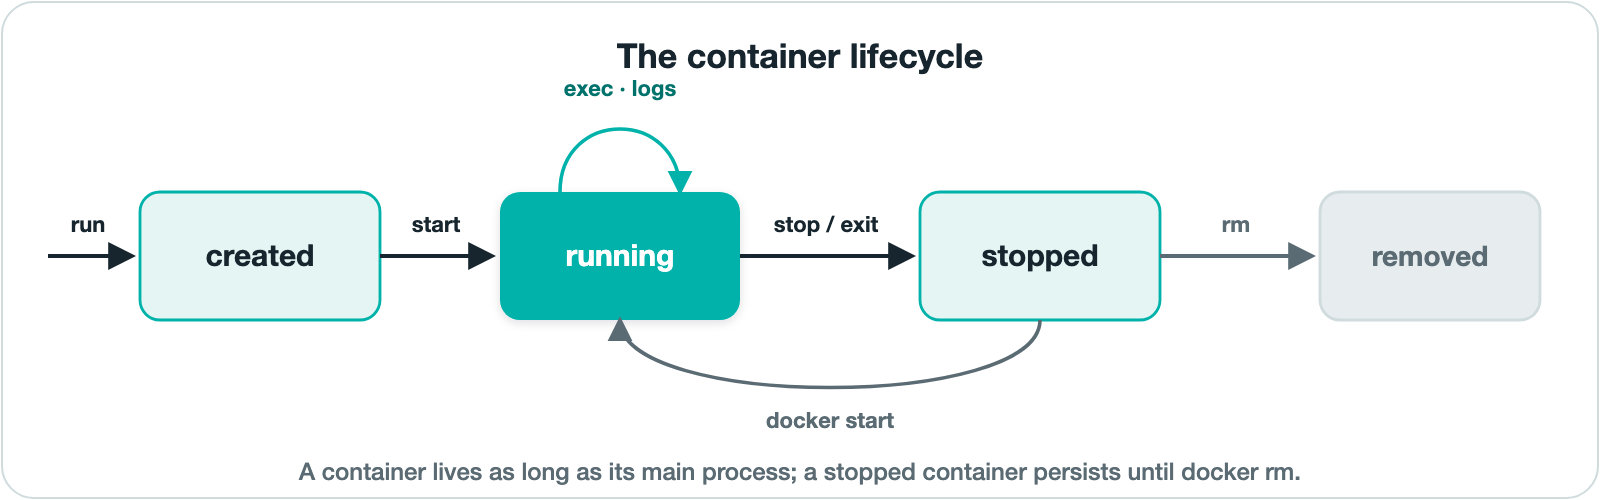<figcaption style="font-size:12.5px;color:#5B6B73;margin-top:8px;line-height:1.45"><b>Figure 3.</b> <code>run</code> → running → stopped → removed. <code>exec</code> and <code>logs</code> act on a running container; a stopped container still exists (and uses disk) until <code>docker rm</code>.</figcaption></figure>

A **stopped** container still exists (and takes disk) until you `docker rm` it. `docker ps -a` shows stopped ones; `docker system prune` reclaims space from stopped containers, dangling images, and unused networks.


## Data that outlives the container — volumes

A container's writable layer is **ephemeral**: `docker rm` and it's gone. For anything you need to keep — a database, model checkpoints, outputs — mount storage from outside the container:

- **`-v $(pwd)/data:/app/data`** — *bind mount* a host directory into the container. Great for development (edit on the host, see it inside instantly) and for reading datasets or writing results.
- **`-v mydata:/app/data`** — a *named volume* managed by Docker. Better for production/state.

```bash
# Reference — mount a host folder for outputs:
docker run --rm -p 8000:8000 \
  -v "$(pwd)/data":/app/data \
  amii-container-demo:0.1
```

Rule of thumb: **code goes in the image; data and secrets come in at runtime** (volumes and `-e` / `--env-file`), never baked into the image.


## Registries — share the image (and keep it private when it must be)

To run your image on Zion, in the cloud, or on a client's infrastructure, you push it to a **registry** and pull it there. There are many; the commands are the same everywhere — `login`, `tag`, `push`, `pull`. What differs is the **address format** and, crucially, the **default visibility**.

### Public vs. private — know the default before you push

An image can leak proprietary code, data paths, or secrets. Some registries publish images **publicly by default**; others are **private by default**. Pushing to the wrong one is how private code ends up world-readable.

| Registry | Address format | Default visibility | Log in with |
|---|---|---|---|
| **Docker Hub** | `docker.io/<user>/<repo>` | **Public** ⚠️ (private repos limited on free tier) | `docker login` |
| **GitHub Container Registry** (ghcr.io) | `ghcr.io/<org>/<repo>` | **Private** (tied to the package's visibility) | token → `docker login ghcr.io` |
| **Google Artifact Registry** (GCP) | `<region>-docker.pkg.dev/<project>/<repo>/<image>` | **Private** (IAM-controlled) | `gcloud auth configure-docker` |
| **Azure Container Registry** (ACR) | `<registry>.azurecr.io/<image>` | **Private** (Entra ID / admin) | `az acr login` |
| **Amazon ECR** (private) | `<acct>.dkr.ecr.<region>.amazonaws.com/<repo>` | **Private** (IAM) | `aws ecr get-login-password` |

> **For client work where the image must stay private, choose a registry that is private by default** — ghcr.io, Google Artifact Registry, Azure ACR, or Amazon ECR. **Docker Hub defaults to public:** a repo you push there is world-readable unless you *explicitly* create it as private. Whichever you pick, **verify the visibility in the registry UI after your first push** — don't assume.

An image name *is* its address: `docker tag` gives an existing image a second name pointing at the registry, and `docker push` uploads it. **All of the blocks below contact live registries and require login, so they are reference blocks — run them in your terminal, not here.** Replace every `<PLACEHOLDER>`.

### Docker Hub — public by default

```bash
docker login                                   # Docker Hub is the default registry
docker tag amii-container-demo:0.1 <DOCKERHUB_USER>/amii-container-demo:0.1
docker push <DOCKERHUB_USER>/amii-container-demo:0.1
# ⚠️ New repos are PUBLIC. Make it private in Docker Hub → repo → Settings if needed.
```

### GitHub Container Registry (ghcr.io) — private by default

Matches your `Amii-Engineering` org and integrates cleanly with GitHub Actions.

```bash
# Personal Access Token (classic) with: write:packages, read:packages
echo "$GITHUB_TOKEN" | docker login ghcr.io -u <GITHUB_USER> --password-stdin
docker tag amii-container-demo:0.1 ghcr.io/amii-engineering/amii-container-demo:0.1
docker push ghcr.io/amii-engineering/amii-container-demo:0.1
# Private by default; publish it explicitly in the package settings only if you want it public.
```

### Google Artifact Registry (GCP) — private by default

```bash
# One-time: let Docker authenticate to Artifact Registry in your region.
gcloud auth configure-docker <REGION>-docker.pkg.dev        # e.g. us-central1-docker.pkg.dev
# (Create the repo once: gcloud artifacts repositories create <REPO> --repository-format=docker --location=<REGION>)
docker tag amii-container-demo:0.1 \
  <REGION>-docker.pkg.dev/<PROJECT_ID>/<REPO>/amii-container-demo:0.1
docker push <REGION>-docker.pkg.dev/<PROJECT_ID>/<REPO>/amii-container-demo:0.1
# Access is governed by IAM; nothing is public unless you grant allUsers the Artifact Registry Reader role.
```

### Azure Container Registry (ACR) — private by default

```bash
az acr login --name <REGISTRY_NAME>                         # authenticates the Docker CLI via Entra ID
docker tag amii-container-demo:0.1 <REGISTRY_NAME>.azurecr.io/amii-container-demo:0.1
docker push <REGISTRY_NAME>.azurecr.io/amii-container-demo:0.1
# Private by default; anonymous pull is off unless you deliberately enable it.
```

### Amazon ECR (private) — private by default

```bash
aws ecr get-login-password --region <REGION> \
  | docker login --username AWS --password-stdin <ACCOUNT_ID>.dkr.ecr.<REGION>.amazonaws.com
# (Create the repo once: aws ecr create-repository --repository-name amii-container-demo)
docker tag amii-container-demo:0.1 \
  <ACCOUNT_ID>.dkr.ecr.<REGION>.amazonaws.com/amii-container-demo:0.1
docker push <ACCOUNT_ID>.dkr.ecr.<REGION>.amazonaws.com/amii-container-demo:0.1
# Note: "ECR Public" (public.ecr.aws) is a SEPARATE, public-by-default service — don't confuse the two.
```

**Tagging discipline:** never rely on `:latest` for anything you need to reproduce. Tag with a version or the Git commit SHA (`:0.1`, `:git-a1b2c3d`) so an image traces back to exact source — the same "pin the exact code behind a result" habit from the Git pillar.


## Closing the loop — build &amp; push from GitHub Actions

You already have CI running tests on every PR. The natural next step: when a change lands on `main`, have CI **build the image and push it to ghcr.io automatically**, so a fresh, tested image is always waiting for Zion to pull. No manual `docker build` on anyone's laptop.

<figure style="text-align:center;margin:1.4em 0">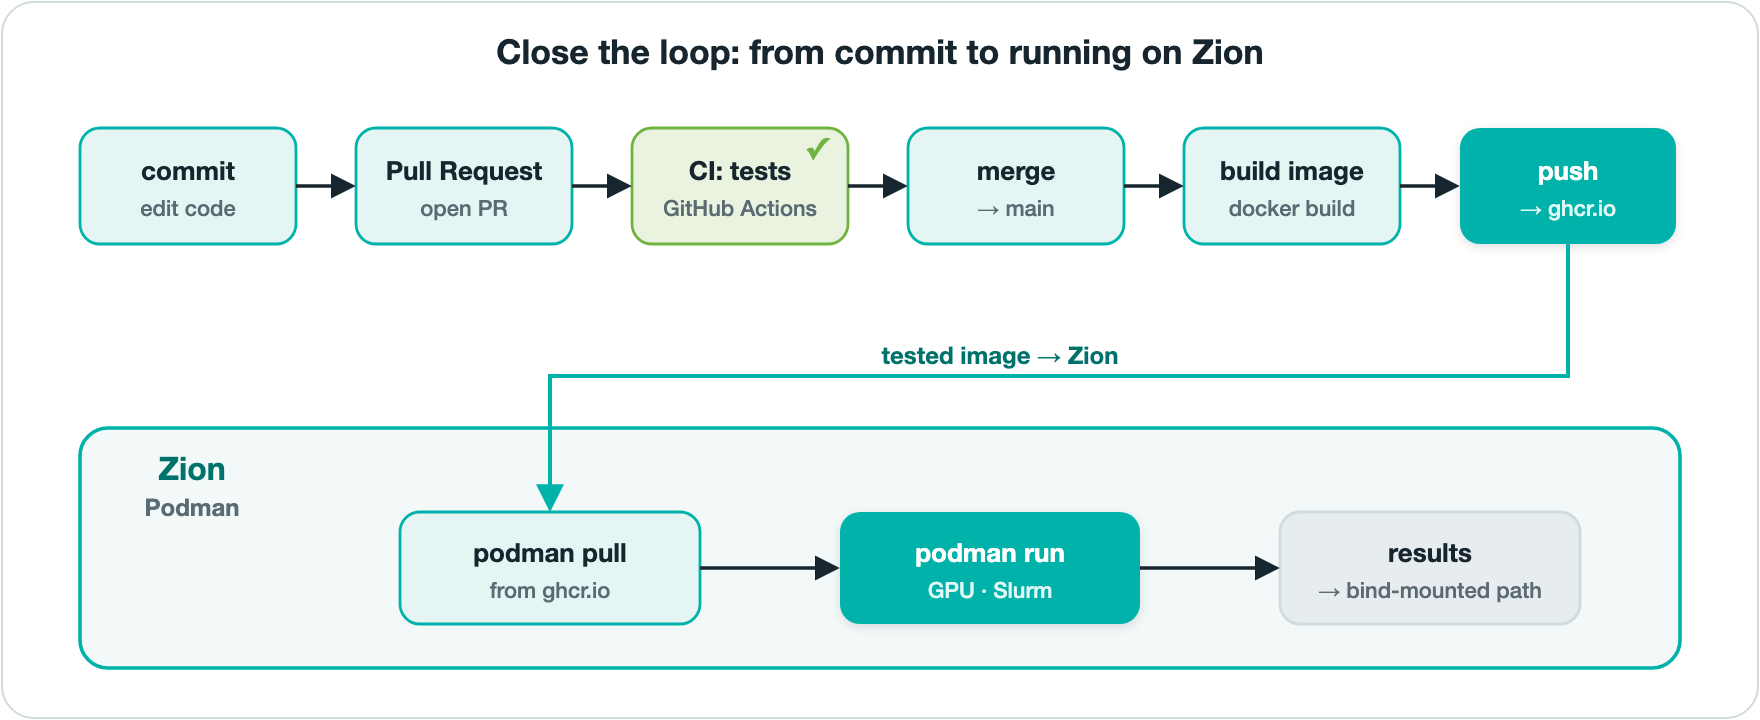<figcaption style="font-size:12.5px;color:#5B6B73;margin-top:8px;line-height:1.45"><b>Figure 4.</b> The whole loop: a commit opens a PR, CI runs the tests, and on merge the image is built and pushed to ghcr.io — then pulled and run on Zion with Podman. The image that passed CI is the one that runs.</figcaption></figure>

This is a reference workflow — drop it in `.github/workflows/docker-publish.yml`:

```yaml
name: Build and publish image
on:
  push:
    branches: [main]
    tags: ['v*']

jobs:
  build-and-push:
    runs-on: ubuntu-latest
    permissions:
      contents: read
      packages: write            # allow pushing to ghcr.io
    steps:
      - uses: actions/checkout@v4

      - name: Log in to ghcr.io
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}   # provided automatically

      - name: Build and push
        uses: docker/build-push-action@v6
        with:
          context: .
          file: ./Dockerfile
          push: true
          tags: |
            ghcr.io/amii-engineering/amii-container-demo:latest
            ghcr.io/amii-engineering/amii-container-demo:${{ github.sha }}
```

Now the chain is complete: **commit → PR → tests (CI) → merge → image built &amp; pushed → pull &amp; run on Zion.**


## Local development — edit in your IDE, run in the container

Everything so far *rebuilds the image to see a change*. That's correct for shipping, but painful while you're actively coding in your IDE: edit → rebuild → run, for every keystroke's worth of progress.

The development pattern fixes this with a **bind-mounted source volume**: mount your project directory from the host *into* the container so the code the container runs **is** the code you're editing. Save a file in VS Code / PyCharm and the change is already inside the container — no rebuild. Pair it with a hot-reloading server (`uvicorn --reload`) and the app restarts itself on save.

<figure style="text-align:center;margin:1.4em 0">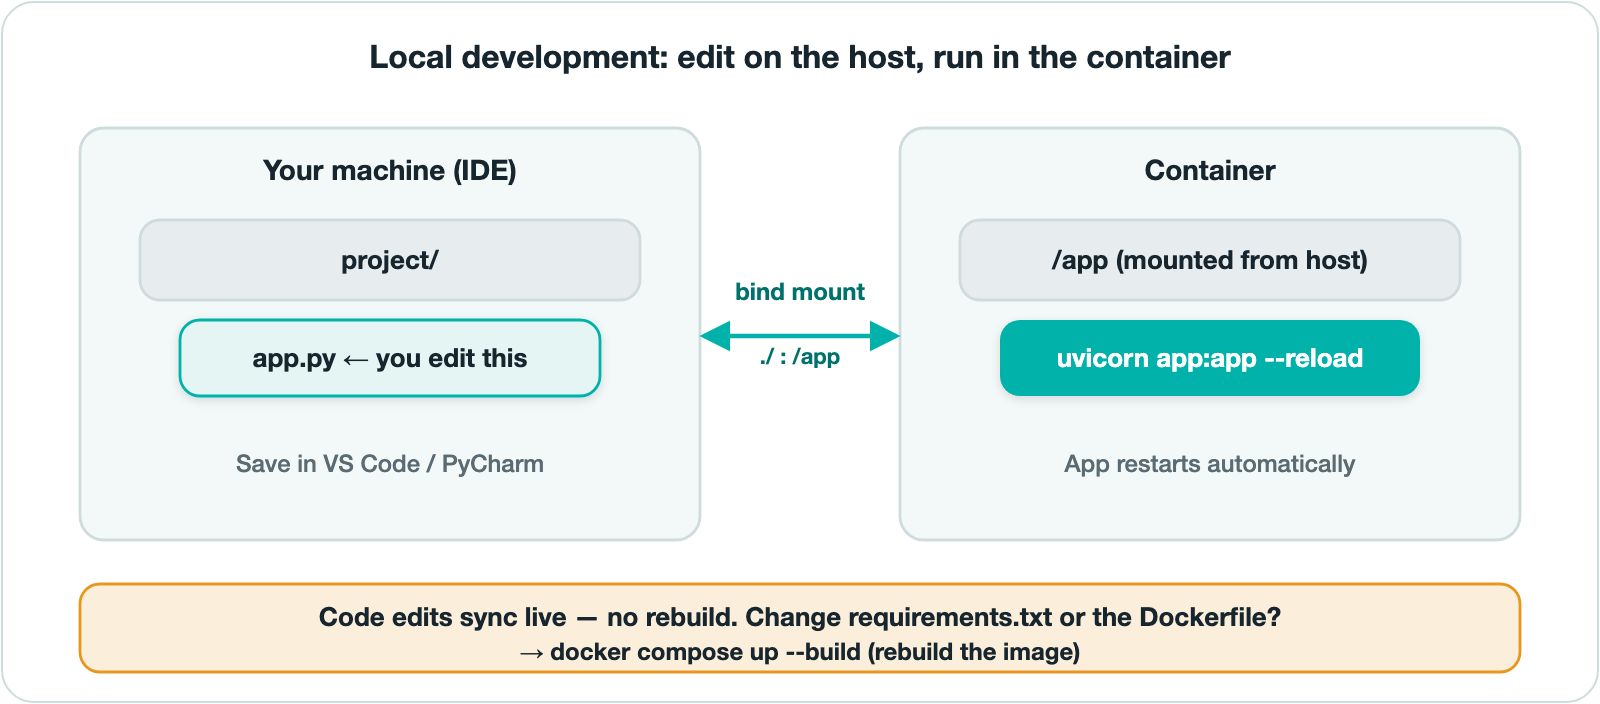<figcaption style="font-size:12.5px;color:#5B6B73;margin-top:8px;line-height:1.45"><b>Figure 5.</b> A bind mount maps your project directory into the container, so it runs the exact code you are editing; <code>--reload</code> restarts the app on save. Only dependency or <code>Dockerfile</code> changes need a rebuild.</figcaption></figure>

**Two kinds of change, two responses:**

- **You edit source (`app.py`)** → the volume syncs it instantly; `--reload` restarts the app. **No rebuild.**
- **You change dependencies or the `Dockerfile`** (`requirements.txt`, new system package) → the *image itself* is stale. **Rebuild it** with `docker compose up --build`. Make `--build` a habit so you never debug against a stale image.

The next cell writes a development-specific Compose file. It mounts the code, forces a reload server, and is meant to be run with `--build`.


In [ ]:
%%writefile docker-compose.dev.yml
# Development compose: source is bind-mounted so IDE edits appear live inside
# the container. Run with:  docker compose -f docker-compose.dev.yml up --build
services:
  api:
    build:
      context: .
      dockerfile: Dockerfile          # rebuilt whenever you pass --build
    volumes:
      - ./:/app                        # sync the WHOLE project into the container
      # Keep container-managed paths from being clobbered by the host mount:
      - /app/__pycache__
    ports:
      - "8000:8000"
    environment:
      GREETING: "hello from dev mode"
      PYTHONUNBUFFERED: "1"
    # Override the image CMD with a hot-reloading server for development:
    command: uvicorn app:app --host 0.0.0.0 --port 8000 --reload


### Run the dev environment

```bash
# --build rebuilds the image (picks up Dockerfile / requirements changes),
# then starts the stack with your live-mounted source:
docker compose -f docker-compose.dev.yml up --build

# Now edit app.py in your IDE and save — uvicorn --reload restarts automatically,
# no rebuild needed. Ctrl-C to stop; add -d to run detached.
```

Compose can also do this without a hand-written volume via **watch mode** (`docker compose watch` with a `develop.watch` block) — it syncs files and can auto-rebuild on dependency changes. The bind-mount above is the explicit, works-everywhere version.

### Get a shell *inside* a running container

To poke around inside a running container — check files, run a one-off command, debug an import — open an interactive shell in it:

```bash
docker exec -it <container_name> /bin/bash      # or /bin/sh on minimal images
```

`-it` = interactive + TTY. Find `<container_name>` with `docker ps`. This is the single most useful debugging command day to day: you're now *inside* the container's filesystem and environment.

### Keeping a "dev box" container alive — the `tail -f /dev/null` trick

A container lives exactly as long as its main process (`CMD`/`ENTRYPOINT`). If that process isn't a long-running service — say you just want a container to `exec` into and run things by hand — it will **start and immediately exit**, and there's nothing to attach to.

The fix is to give the container a command that never returns, so it stays up until you stop it:

```dockerfile
ENTRYPOINT ["tail", "-f", "/dev/null"]
# or
CMD ["tail", "-f", "/dev/null"]
```

*"then the container won't despawn if you're not running a long-winded service."*

`tail -f /dev/null` blocks forever using no CPU. The container stays alive, and you `docker exec -it <name> /bin/bash` into it whenever you like — a persistent, disposable Linux box with your project mounted. Perfect for a dev container you drive interactively rather than one that serves traffic.


## More than one container — Docker Compose

Real services rarely run alone: an API plus a database plus a cache. **Compose** declares a multi-container setup in one `docker-compose.yml` and runs it with a single command. Here our API gets a companion Redis, wired together on a private network Compose creates automatically.


In [ ]:
%%writefile docker-compose.yml
services:
  api:
    build:
      context: .
      dockerfile: Dockerfile
    ports:
      - "8000:8000"
    environment:
      GREETING: "hello from compose"
    depends_on:
      - redis

  redis:
    image: redis:7-alpine
    # No ports published: only the api container can reach it, by the name "redis".


```bash
# Reference — run the whole stack:
docker compose up --build        # start everything, stream logs
docker compose ps                # what is running
docker compose down              # stop and remove the stack
```

Inside the `api` container, the database is reachable simply as the hostname `redis` — Compose's built-in DNS resolves service names on the shared network. This is the same model Kubernetes scales up to later.


## Stop memorizing flags — wrap them in Make or `just`

`docker run -d --rm --name demo -p 8000:8000 -e GREETING=... image:tag` is a lot to retype correctly. Teams put these commands behind short, memorable targets so everyone runs them the same way: `make build`, `make start`, `make stop`. New teammates read the file to learn the project's workflow.

### Make — everywhere already

`make` ships on virtually every Unix machine. One gotcha: **recipe lines must be indented with a real TAB**, not spaces.

```makefile
IMAGE := amii-container-demo
TAG   := 0.1
NAME  := demo

build:            ## Build the image
	docker build -t $(IMAGE):$(TAG) .

start:            ## Run the container in the background
	docker run -d --rm --name $(NAME) -p 8000:8000 -e GREETING="hi" $(IMAGE):$(TAG)

stop:             ## Stop (and, via --rm, remove) the container
	docker stop $(NAME)

logs:             ## Follow the container's logs
	docker logs -f $(NAME)

shell:            ## Open an interactive shell inside the running container
	docker exec -it $(NAME) /bin/bash

dev:              ## Start the live-reload dev environment
	docker compose -f docker-compose.dev.yml up --build

.PHONY: build start stop logs shell dev
```

```bash
make build        # then...
make start
make shell        # drop into the container
make stop
```

### `just` — a modern alternative

[`just`](https://github.com/casey/just) is a purpose-built command runner: no tab pitfalls, built-in `--list`, easy recipe arguments, and `.env` support. Same idea, friendlier file (a `justfile`):

```just
image := "amii-container-demo"
tag   := "0.1"
name  := "demo"

# Build the image
build:
    docker build -t {{image}}:{{tag}} .

# Run the container in the background
start:
    docker run -d --rm --name {{name}} -p 8000:8000 -e GREETING="hi" {{image}}:{{tag}}

# Stop the container
stop:
    docker stop {{name}}

# Shell into the running container
shell:
    docker exec -it {{name}} /bin/bash

# Live-reload dev environment
dev:
    docker compose -f docker-compose.dev.yml up --build
```

```bash
just --list       # self-documenting: shows every recipe and its comment
just build
just start
```

Either way, the payoff is the same: the correct, project-specific commands live in version control, so nobody has to remember flags and everyone runs the container identically — the same reproducibility habit, applied to your own workflow.


## Podman — the rootless, daemonless drop-in

**Podman** runs the same OCI images with a nearly identical CLI, but with two differences that matter on shared servers:

- **Daemonless** — no background root daemon; each command is a normal process.
- **Rootless by default** — containers run as *your* user, not root. On multi-user machines like Zion, this is often the *only* engine allowed, because a rootful Docker daemon effectively grants root on the host.

The commands you already learned transfer directly:

```bash
podman build -t amii-container-demo:0.1 .
podman run -d --rm -p 8000:8000 amii-container-demo:0.1
podman ps
podman login ghcr.io -u <GITHUB_USER>
podman push ghcr.io/amii-engineering/amii-container-demo:0.1

# Most scripts work unchanged with:
alias docker=podman
```

`podman generate systemd` (or Quadlet) can even turn a container into a managed service — handy for long-running jobs on a server. If Podman is your Zion engine, everything above in this notebook applies as-is; just swap the command name.


## Apptainer / Singularity — the HPC runtime

Many research and HPC clusters don't allow Docker at all (that root daemon again). Instead they use **Apptainer** (formerly **Singularity**), built for shared, multi-user, GPU compute:

- Runs as **your user** — no root, safe on shared nodes.
- An image is a **single `.sif` file** you can copy around like any file (no daemon, no local registry).
- **Pulls directly from Docker/ghcr registries** and converts to `.sif` — so the image you built and pushed above works here unchanged.
- The host filesystem (your home, project, scratch) is mounted **by default**, which fits HPC data layouts.

```bash
# Pull your pushed image and convert it to a .sif file:
apptainer pull demo.sif docker://ghcr.io/amii-engineering/amii-container-demo:0.1
#   (Docker Hub instead:  docker://docker.io/<DOCKERHUB_USER>/amii-container-demo:0.1)

# Run the image's default command:
apptainer run demo.sif

# Or run a specific command inside it:
apptainer exec demo.sif uvicorn app:app --host 0.0.0.0 --port 8000

# GPU passthrough (NVIDIA) — the killer feature on compute nodes:
apptainer exec --nv demo.sif python -c "import os; print('gpu-ready')"

# Bind a host directory (data / outputs) into the container:
apptainer exec --bind /project/data:/app/data demo.sif ls /app/data
```

**Key mental-model shift from Docker:** there is no daemon and no `-d`/`docker ps`. An Apptainer container is just a *process you started* — it lives and dies with your shell or your Slurm job. Ports aren't "published"; the process shares the host network directly.


## Running on Zion

> **Placeholders:** the exact hostname, scheduler, partition, and paths on Zion are site-specific. Confirm them with the Advanced Technology team and replace every `<PLACEHOLDER>` below. The workflow is the same everywhere: **get on the node → pull the image → run it (with GPUs) → get your results back.**

We use **Podman** on Zion. It's the right fit for a shared server: **rootless** (containers run as *your* user, never root on the host) and **daemonless** (no privileged background service), while accepting the exact same OCI image you built and pushed earlier — the commands are the ones you already know from Docker.

### Step 1 — Get on the server

```bash
# From your laptop:
ssh <USERNAME>@<ZION_HOSTNAME>          # confirm the real host with Advanced Technology
```

### Step 2 — Pull the image with Podman

```bash
# Public image:
podman pull ghcr.io/amii-engineering/amii-container-demo:0.1

# Private image — log in first with a token (ghcr.io or Docker Hub), as shown earlier:
echo "$GITHUB_TOKEN" | podman login ghcr.io -u <GITHUB_USER> --password-stdin
podman pull ghcr.io/amii-engineering/amii-container-demo:0.1
```

### Step 3a — Run directly on a node (interactive / no scheduler)

Use this when you have an interactive shell on a compute node and just want to run something now.

```bash
podman run --rm --device nvidia.com/gpu=all \
  -v /project/<GROUP>/data:/app/data \
  ghcr.io/amii-engineering/amii-container-demo:0.1 python your_script.py
```

> **GPU flag:** rootless Podman uses the **CDI** interface for GPUs — `--device nvidia.com/gpu=all` (requires the NVIDIA Container Toolkit / CDI to be configured on Zion). Some setups still accept `--gpus all`. Confirm which one Zion expects.

### Step 3b — Submit as a Slurm batch job (scheduled clusters)

If Zion uses a scheduler (Slurm is the common one), you don't run on the login node — you **submit a job** and it lands on a GPU node. Save this as `run_demo.slurm`:

```bash
#!/bin/bash
#SBATCH --job-name=amii-demo
#SBATCH --partition=<GPU_PARTITION>     # confirm partition name
#SBATCH --gres=gpu:1                    # request 1 GPU
#SBATCH --cpus-per-task=4
#SBATCH --mem=16G
#SBATCH --time=00:30:00
#SBATCH --output=demo-%j.log            # %j = job id

# Run the container on the allocated GPU node with Podman:
podman run --rm --device nvidia.com/gpu=all \
  -v /project/<GROUP>/data:/app/data \
  ghcr.io/amii-engineering/amii-container-demo:0.1 python your_script.py
```

```bash
# Submit, watch, inspect:
sbatch run_demo.slurm          # queue the job
squeue -u $USER                # your jobs and their state
cat demo-<JOBID>.log           # output once it runs
scancel <JOBID>                # cancel if needed
```

### A note on long-running *services* vs. batch *jobs*

The FastAPI demo is a **service** (it stays up and listens on a port). On a cluster that pattern is unusual — clusters are built for **batch jobs** that start, compute, write results, and exit. For the workshop, treat `python your_script.py` above as *your training or inference job*. If you genuinely need a long-running service on Zion (e.g. an inference endpoint), talk to the Advanced Technology team about port forwarding and allowed runtimes — that's a deployment decision, not a `podman run`.

### Getting results back

Results should be written to a **bind-mounted host path** (`/project/.../data`, scratch, or your home), *not* into the container's ephemeral layer. Then copy them to your laptop:

```bash
scp <USERNAME>@<ZION_HOSTNAME>:/project/<GROUP>/data/results.csv .
```


## Best practices &amp; high-leverage habits

- **Pin everything** — base image tag (`python:3.11-slim`, not `latest`) and every dependency version. Reproducibility is the whole point.
- **Order layers by change frequency** — dependencies before source, so edits don't trigger slow reinstalls.
- **Keep images small** — `-slim`/`alpine` bases and a good `.dockerignore`. Smaller = faster pulls to Zion + smaller attack surface.
- **Never bake in secrets or data** — pass them at runtime (`-e`, `--env-file`, volumes). A secret in an image layer is there forever, even if a later layer "deletes" it.
- **Run as non-root** — a `USER` line is cheap insurance.
- **One concern per image** — API in one, database in another; wire them with Compose or the cluster.
- **Tag with the commit SHA** — an image should trace back to the exact code that built it, just like a Git tag pins the code behind a result.
- **Let CI build the image** — humans build images inconsistently; a pipeline builds them the same way every time.
- **Match the engine to the host** — Docker on your laptop and CI, but **Apptainer/Podman on shared GPU servers like Zion**. The image is the same; only the run command changes.

## Wrap-up

You built a real image from a Dockerfile, ran and inspected it, pushed it to Docker Hub and ghcr.io, wired CI to build it automatically, and saw how to pull and run it on Zion with Docker, Podman, and Apptainer — directly and through Slurm.

The through-line across all four workshops: **Git** captures the code, **tests** prove it works, **CI/CD** runs those proofs automatically, and **containers** ship the proven code as one artifact that runs identically everywhere — including Zion.

### Clean up your machine

```bash
docker compose down 2>/dev/null
docker rm -f demo 2>/dev/null
docker rmi amii-container-demo:0.1 2>/dev/null
docker system prune -f          # reclaim space from stopped containers & dangling images
# The scratch folder itself:
#   rm -rf docker-workshop-sandbox
```

Thank you! Questions welcome.
